In [17]:
from FormUtils import  pyForm, capture_physics_expr

In [18]:
%%pyForm Compton

* Process: e- gamma -> e- gamma (Compton)
#-
* Above suppresses extra output
Off Statistics;
Off FinalStats;
#include amplitude.inc

* Kinematic variables
Symbols s, t, u, me, E3E1ratioSq, PreFac;
* constants
Symbols e, pi, alpha;

* Contracts: UB(i1) -> g(i1,i2,mu2) -> fprop(i2,i3,p1+p2) -> g(i3,i4,mu1) -> U(i4)
Local Ms = (e^2) * UB(i1, p3, me) * g(i1, i2, mu2) 
                 * fprop(i2, i3, q1, me) 
                 * g(i3, i4, mu1) * U(i4, p1, me)
                 * eps(mu1, p2) * eps(mu2, p4);

* Contracts: UB(i1) -> g(i1,i2,mu1) -> fprop(i2,i3,p1-p4) -> g(i3,i4,mu2) -> U(i4)
Local Mu = (e^2) * UB(i1, p3, me) * g(i1, i2, mu1) 
                 * fprop(i2, i3, q2 , me) 
                 * g(i3, i4, mu2) * U(i4, p1, me)
                 * eps(mu1, p2) * eps(mu2, p4);
                

Local Mtot = Ms + Mu;

* Square the total amplitude
#call squareamplitude(Mtot, Msq)
.sort
* Average over initial spins (1/2) and polarizations (1/2) = 1/4
multiply 1/4;
.sort 

* conservation
id q1 = p1 + p2;
id q2 = p1 - p4;
.sort
* propagator handling
id prop(x?) = (x)^-1;
.sort
id (q1.q1)^-1 = (s)^-1;
id (q2.q2)^-1 = (u)^-1;
id (-me^2 + q1.q1)^-1 = (s - me^2)^-1;
id (-me^2 + q2.q2)^-1 = (u - me^2)^-1;
.sort 
* Mandelstam 
id q1.q1 = s;
id q2.q2 = u;
.sort
repeat;
    id p1.p1 = me^2;
    id p3.p3 = me^2;
    id p2.p2 = 0;
    id p4.p4 = 0;

    id p1.p2 = (s - me^2)/2;
    id p3.p4 = (s - me^2)/2;
    id p1.p4 = (me^2 - u)/2;
    id p2.p3 = (me^2 - u)/2;
    id p1.p3 = (2*me^2 - t)/2;
    id p2.p4 = -t/2;
endrepeat;
.sort
id e^4 = 16 * pi^2 * alpha^2;
.sort
Local dSigmaLab = PreFac * Msq;
.sort
id PreFac = ((1 / (64 * pi^2 * me^2)) * E3E1ratioSq);
.sort

Bracket s, alpha,E3E1ratioSq, pi ;
.sort
* Save
Format C;
#write <Compton.txt> "%e;", dSigmaLab;
.sort

* Print
Format;
Format;
Print+s  Msq;
Print+s  dSigmaLab;
.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Fri Apr 10 18:11:30 2026
    
    * Process: e- gamma -> e- gamma (Compton)
    #-

   Msq =
       - 96/( - me^2 + u)/( - me^2 + u)*me^4*pi^2*alpha^2
       + 160/( - me^2 + u)/( - me^2 + u)*u*me^2*pi^2*alpha^2
       + 64/( - me^2 + u)/( - me^2 + u)*t*me^2*pi^2*alpha^2
       + 96/( - me^2 + u)/( - me^2 + u)*s*me^2*pi^2*alpha^2
       - 32/( - me^2 + u)/( - me^2 + u)*s*u*pi^2*alpha^2
       + 384/( - me^2 + s)/( - me^2 + u)*me^4*pi^2*alpha^2
       - 64/( - me^2 + s)/( - me^2 + u)*u*me^2*pi^2*alpha^2
       - 256/( - me^2 + s)/( - me^2 + u)*t*me^2*pi^2*alpha^2
       + 64/( - me^2 + s)/( - me^2 + u)*t*u*pi^2*alpha^2
       + 64/( - me^2 + s)/( - me^2 + u)*t^2*pi^2*alpha^2
       - 64/( - me^2 + s)/( - me^2 + u)*s*me^2*pi^2*alpha^2
       + 64/( - me^2 + s)/( - me^2 + u)*s*t*pi^2*alpha^2
       - 96/( - me^2 + s)/( - me^2 + s)*me^4*pi^2*alpha^2
       + 96/( - me^2 + s)/( - me^2 + s)*u*me^2*pi^2*alpha^2
       + 64/( - me^2 + s)/( 

Captured Expression: +E3E1ratioSq*pow(alpha,2)*(-3./2./(-pow(me,2)+u)/(-pow(me,2)+u)*pow(me,2)+5./2./(-pow(me,2)+u)/(-pow(me,2)+u)*u+1/(-pow(me,2)+u)/(-pow(me,2)+u)*t+6/(-pow(me,2)+s)/(-pow(me,2)+u)*pow(me,2)-1/(-pow(me,2)+s)/(-pow(me,2)+u)*u-4/(-pow(me,2)+s)/(-pow(me,2)+u)*t+1/(-pow(me,2)+s)/(-pow(me,2)+u)*t*u*pow(me,-2)+1/(-pow(me,2)+s)/(-pow(me,2)+u)*pow(t,2)*pow(me,-2)-3./2./(-pow(me,2)+s)/(-pow(me,2)+s)*pow(me,2)+3./2./(-pow(me,2)+s)/(-pow(me,2)+s)*u+1/(-pow(me,2)+s)/(-pow(me,2)+s)*t)+s*E3E1ratioSq*pow(alpha,2)*(3./2./(-pow(me,2)+u)/(-pow(me,2)+u)-1./2./(-pow(me,2)+u)/(-pow(me,2)+u)*u*pow(me,-2)-1/(-pow(me,2)+s)/(-pow(me,2)+u)+1/(-pow(me,2)+s)/(-pow(me,2)+u)*t*pow(me,-2)+5./2./(-pow(me,2)+s)/(-pow(me,2)+s)-1./2./(-pow(me,2)+s)/(-pow(me,2)+s)*u*pow(me,-2))


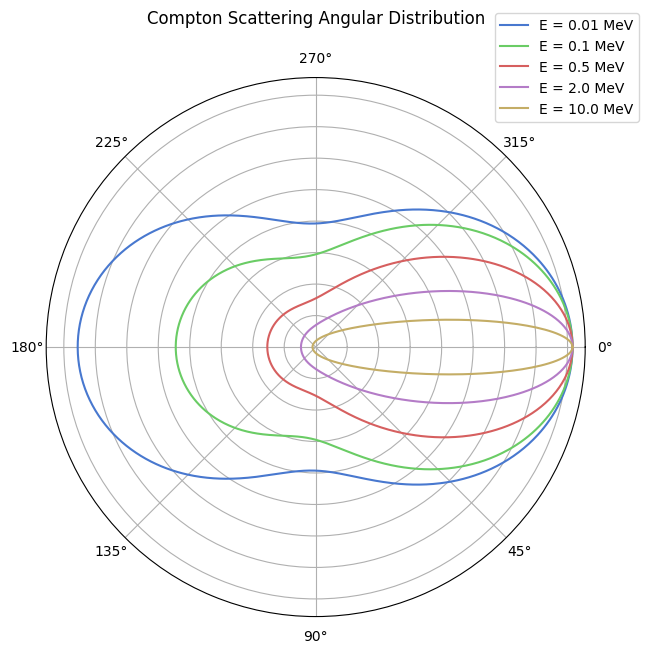

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from Kinematics import  kinematics2To2Lab

plt.style.use('seaborn-v0_8-muted') 
plt.rcParams['axes.grid'] = True


# Capture 
form_expr = capture_physics_expr("scripts/Compton.txt")
print(f"Captured Expression: {form_expr}")

# Constants
me = 0.51099895
alpha = 1/137.035999
energies = [0.01, 0.1, 0.5, 2.0, 10.0]  # MeV

# Setup the Plot
fig = plt.figure(figsize=(10, 7))
ax = plt.subplot(111, polar=True)
theta_vals = np.linspace(0, 2*np.pi, 1000)

for E1 in energies:
    cross_section = []
    for theta in theta_vals:
        # 1. Get Kinematics for this angle
        s_val, t_val, u_val, ratio_val = kinematics2To2Lab(E1, theta, me)
        
        # 2. Define context for eval()
        context = {
            's': s_val, 't': t_val, 'u': u_val, 
            'me': me, 'alpha': alpha, 
            'E3E1ratioSq': ratio_val,
            'pow': pow
        }
        res = eval(form_expr, context)
        cross_section.append(res)
    
    # Plotting
    ax.plot(theta_vals, cross_section, label=f'E = {E1} MeV')
ax.set_theta_zero_location("E")  # 0 deg at right
ax.set_theta_direction(-1)       # Clockwise
ax.set_yticklabels([])
ax.set_title("Compton Scattering Angular Distribution", pad=20)
ax.legend(loc='upper right',bbox_to_anchor=(1.1, 1.12), borderaxespad=0.)

plt.show()

